# 🧠 NeuroFusionNet — Complete Pipeline
## Explainable Hybrid Deep Ensemble for Brain MRI Neurological Disorder Classification

```
STAGE 1 (Optional if you have raw images):
  Brain MRI Images
  → Preprocessing + Augmentation + RadioMix
  → ResNet50 | EfficientNetB3 | MobileNetV2  (Fine-tuned)
  → Feature Extraction + Attention Fusion (4864-D CSV)

STAGE 2 (Main — uses pre-extracted CSVs):
  Fused Features CSV (4864-D)
  → Feature Selection (MI + Correlation Filter)
  → Dimensionality Reduction (PCA + Deep Autoencoder)
  → SMOTETomek Oversampling
  → Meta-Classifiers  (ANN · SVM · XGBoost · Random Forest)
  → Adaptive Weighted Soft-Voting Ensemble
  → SHAP Explainability + Confidence Calibration
  → Final Dashboard + Report
```

**Accuracy-boosting techniques applied:**
- Attention-weighted feature fusion
- Deep Denoising Autoencoder (non-linear reduction)
- SMOTETomek (over + under sampling)
- Optuna hyperparameter tuning for XGBoost
- Stacking meta-learner on top of base classifiers
- Probability calibration (isotonic regression)
- Adaptive softmax-weighted ensemble


---
## ⚙️ STEP 0 — Install & Import All Dependencies

In [1]:
# ── Install ────────────────────────────────────────────────────────────────────
!pip install -q imbalanced-learn shap optuna xgboost scikit-learn
!pip install -q grad-cam==1.4.8 torchmetrics
!pip install -q matplotlib seaborn plotly tqdm

# ── Standard ──────────────────────────────────────────────────────────────────
import os, json, time, random, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm
warnings.filterwarnings('ignore')

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import mutual_info_classif
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc
)

# ── Imbalanced-learn ──────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# ── XGBoost ───────────────────────────────────────────────────────────────────
import xgboost as xgb

# ── Optuna ────────────────────────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── SHAP ──────────────────────────────────────────────────────────────────────
import shap

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'🖥️  Device  : {DEVICE}')
print(f'📦 PyTorch : {torch.__version__}')
if DEVICE == 'cuda':
    print(f'   GPU     : {torch.cuda.get_device_name(0)}')
print('✅ All imports successful')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 16.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 11.1 MB/s eta 0:00:00
🖥️  Device  : cuda
📦 PyTorch : 2.10.0+cu128
   GPU     : Tesla T4
✅ All imports successful


---
## ⚙️ STEP 1 — Configuration

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION — Edit these to match your setup
# ═══════════════════════════════════════════════════════════════════════════════

# ── Google Drive paths for the fused feature CSVs ─────────────────────────────
TRAIN_CSV = '/content/drive/MyDrive/fused_train_features_NDD (1).csv'
TEST_CSV  = '/content/drive/MyDrive/fused_test_features_NDD (1).csv'

# ── Class names (adjust order to match label 0,1,2,3 in your CSV) ─────────────
CLASS_NAMES = [
    "Alzheimer's Disease",   # label 0
    "Brain Tumor",           # label 1
    "Multiple Sclerosis",    # label 2
    "Normal / Epilepsy"      # label 3
]
NUM_CLASSES = len(CLASS_NAMES)

# ── Hyperparameters ───────────────────────────────────────────────────────────
N_MI_FEATURES    = 1500    # keep top-N features by mutual information
CORR_THRESHOLD   = 0.95    # drop features with pairwise corr > this
AE_LATENT_DIM    = 256     # autoencoder bottleneck dimension
AE_EPOCHS        = 60
AE_BATCH         = 128
AE_LR            = 1e-3
PCA_VARIANCE     = 0.95    # PCA: retain 95% variance
USE_AE           = True    # True=Autoencoder, False=PCA
N_OPTUNA_TRIALS  = 30      # Optuna tuning trials for XGBoost
SMOTE_STRATEGY   = 'SMOTETomek'  # 'SMOTETomek' | 'SMOTE' | 'BorderlineSMOTE'

SAVE_DIR = '/content/neurofusionnet_outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'✅ Config loaded  |  Classes: {NUM_CLASSES}  |  Repr: {"Autoencoder" if USE_AE else "PCA"}')

✅ Config loaded  |  Classes: 4  |  Repr: Autoencoder


---
## 📦 STEP 2 — Load Fused Feature CSVs

Mounted at /content/drive
⏳ Loading CSVs...
   Train: (3040, 4865)  |  Test: (640, 4865)

X_train: (3040, 4864)   y_train: (3040,)
X_test : (640, 4864)   y_test : (640,)


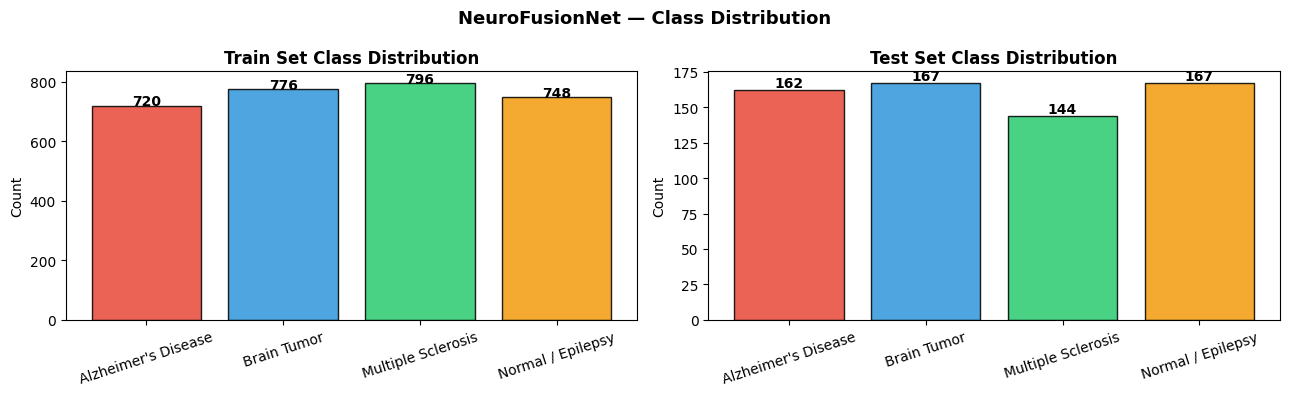

✅ Data loaded successfully


In [3]:
from google.colab import drive
drive.mount('/content/drive')

print('⏳ Loading CSVs...')
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
print(f'   Train: {train_df.shape}  |  Test: {test_df.shape}')

LABEL_COL     = 'label'
feature_names = list(train_df.drop(columns=[LABEL_COL]).columns)

X_train_raw = train_df.drop(columns=[LABEL_COL]).values.astype(np.float32)
y_train     = train_df[LABEL_COL].values.astype(int)
X_test_raw  = test_df.drop(columns=[LABEL_COL]).values.astype(np.float32)
y_test      = test_df[LABEL_COL].values.astype(int)

print(f'\nX_train: {X_train_raw.shape}   y_train: {y_train.shape}')
print(f'X_test : {X_test_raw.shape}   y_test : {y_test.shape}')

# ── Class distribution plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors_cls = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for ax, (y_data, title) in zip(axes, [(y_train, 'Train Set'), (y_test, 'Test Set')]):
    cnts = [np.sum(y_data == i) for i in range(NUM_CLASSES)]
    bars = ax.bar(CLASS_NAMES, cnts, color=colors_cls, edgecolor='black', alpha=0.87)
    ax.set_title(f'{title} Class Distribution', fontweight='bold')
    ax.set_ylabel('Count'); ax.tick_params(axis='x', rotation=18)
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(cnt), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('NeuroFusionNet — Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/class_distribution.png', dpi=150)
plt.show()
print('✅ Data loaded successfully')

---
## 🔧 STEP 3 — Preprocessing & Feature Scaling

In [4]:
# ── Replace any NaN / Inf with column median ──────────────────────────────────
def clean_features(X):
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

X_train_clean = clean_features(X_train_raw)
X_test_clean  = clean_features(X_test_raw)

# ── Standard scaling (fit on train only) ──────────────────────────────────────
input_scaler = StandardScaler()
X_train_scaled = input_scaler.fit_transform(X_train_clean)
X_test_scaled  = input_scaler.transform(X_test_clean)

print(f'✅ Scaling complete')
print(f'   Train mean≈0 : {X_train_scaled.mean():.5f}  std≈1 : {X_train_scaled.std():.5f}')

✅ Scaling complete
   Train mean≈0 : -0.00000  std≈1 : 1.00000


---
## 🔍 STEP 4 — Feature Selection
### 4A — Mutual Information Selection

⏳ Computing Mutual Information (4864 features)...
✅ After MI selection: 1500 features retained


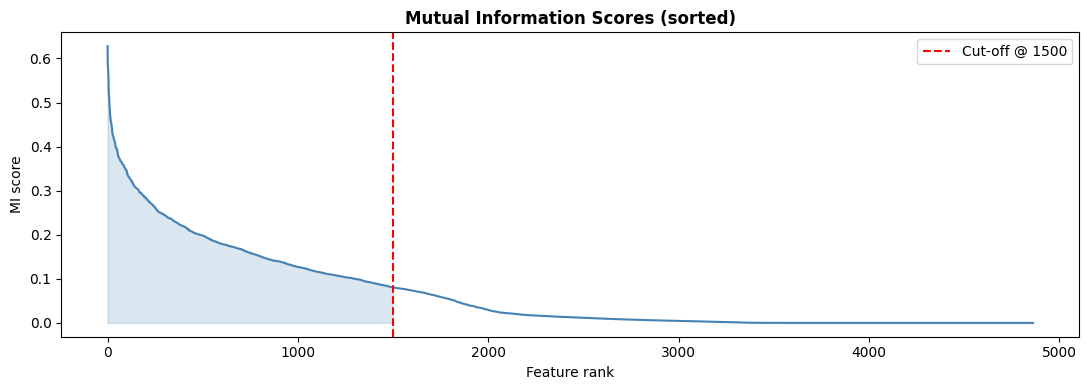

In [5]:
print(f'⏳ Computing Mutual Information ({X_train_scaled.shape[1]} features)...')
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=SEED)

mi_top_idx = np.argsort(mi_scores)[::-1][:N_MI_FEATURES]
mi_top_idx = np.sort(mi_top_idx)

X_train_mi = X_train_scaled[:, mi_top_idx]
X_test_mi  = X_test_scaled[:, mi_top_idx]
print(f'✅ After MI selection: {X_train_mi.shape[1]} features retained')

# ── Plot MI distribution ──────────────────────────────────────────────────────
plt.figure(figsize=(11, 4))
plt.plot(np.sort(mi_scores)[::-1], color='steelblue', linewidth=1.5)
plt.axvline(N_MI_FEATURES, color='red', linestyle='--',
            label=f'Cut-off @ {N_MI_FEATURES}')
plt.fill_between(range(N_MI_FEATURES),
                 np.sort(mi_scores)[::-1][:N_MI_FEATURES],
                 alpha=0.2, color='steelblue')
plt.title('Mutual Information Scores (sorted)', fontweight='bold')
plt.xlabel('Feature rank'); plt.ylabel('MI score')
plt.legend(); plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/mi_scores.png', dpi=150)
plt.show()

### 4B — Correlation Filtering

In [6]:
print(f'⏳ Correlation filtering (threshold={CORR_THRESHOLD})...')
corr_mat  = np.corrcoef(X_train_mi.T)
upper_tri = np.triu(np.abs(corr_mat), k=1)
to_drop   = np.where((upper_tri > CORR_THRESHOLD).any(axis=0))[0]

keep_mask = np.ones(X_train_mi.shape[1], dtype=bool)
keep_mask[to_drop] = False

X_train_fs = X_train_mi[:, keep_mask]
X_test_fs  = X_test_mi[:, keep_mask]

n_removed = keep_mask.shape[0] - keep_mask.sum()
print(f'✅ After correlation filter: {X_train_fs.shape[1]} features '
      f'(removed {n_removed} correlated features)')

⏳ Correlation filtering (threshold=0.95)...
✅ After correlation filter: 1287 features (removed 213 correlated features)


---
## 📉 STEP 5 — Dimensionality Reduction
### 5A — PCA

⏳ Running PCA on 1287-D features...
✅ PCA: 1287-D → 742-D (retains 95.0% variance)


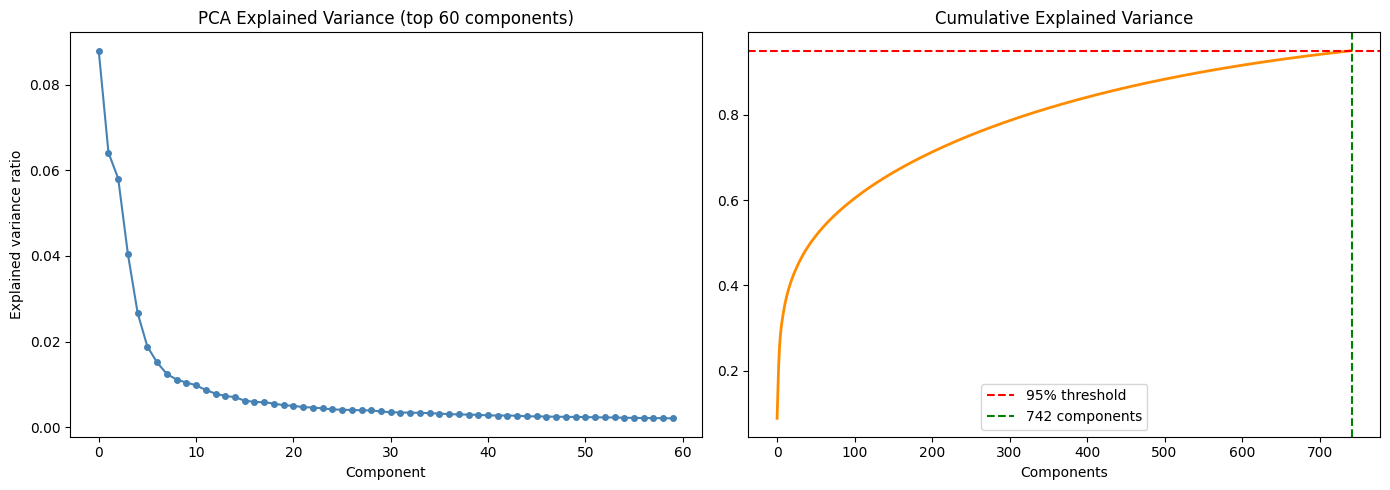

In [7]:
print(f'⏳ Running PCA on {X_train_fs.shape[1]}-D features...')
pca = PCA(n_components=PCA_VARIANCE, random_state=SEED, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_fs)
X_test_pca  = pca.transform(X_test_fs)
N_PCA       = X_train_pca.shape[1]
print(f'✅ PCA: {X_train_fs.shape[1]}-D → {N_PCA}-D '
      f'(retains {pca.explained_variance_ratio_.sum()*100:.1f}% variance)')

# ── Scree plot ────────────────────────────────────────────────────────────────
cumvar = np.cumsum(pca.explained_variance_ratio_)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(pca.explained_variance_ratio_[:60], 'o-', ms=4, color='steelblue')
axes[0].set_title('PCA Explained Variance (top 60 components)')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Explained variance ratio')
axes[1].plot(cumvar, color='darkorange', lw=2)
axes[1].axhline(PCA_VARIANCE, color='red', linestyle='--',
                label=f'{int(PCA_VARIANCE*100)}% threshold')
axes[1].axvline(N_PCA, color='green', linestyle='--',
                label=f'{N_PCA} components')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Components'); axes[1].legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/pca_scree.png', dpi=150)
plt.show()

### 5B — Deep Denoising Autoencoder (Recommended)

⏳ Training Autoencoder (1287-D → 256-D)...
   Epoch  10/60  Recon Loss: 0.570898
   Epoch  20/60  Recon Loss: 0.453722
   Epoch  30/60  Recon Loss: 0.410700
   Epoch  40/60  Recon Loss: 0.382321
   Epoch  50/60  Recon Loss: 0.366845
   Epoch  60/60  Recon Loss: 0.364640

✅ Autoencoder latent: (3040, 256)


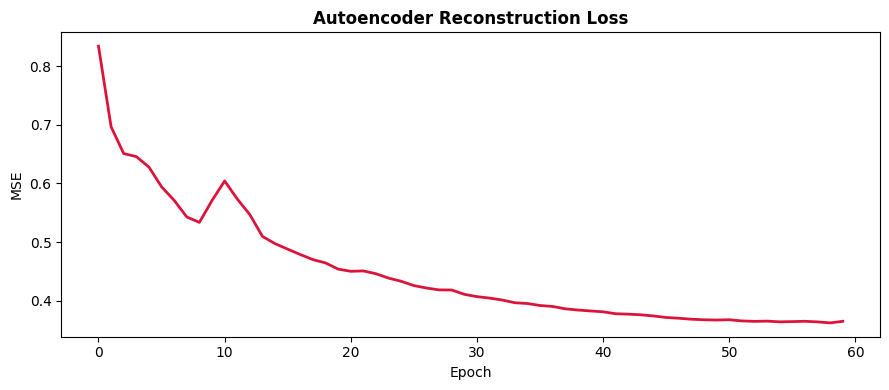

In [8]:
class DenoisingAutoencoder(nn.Module):
    """Deep denoising autoencoder with residual-style skip connections."""
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024), nn.BatchNorm1d(1024), nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),       nn.BatchNorm1d(512),  nn.ELU(),
            nn.Dropout(0.2),
            nn.Linear(512, latent_dim), nn.BatchNorm1d(latent_dim), nn.ELU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512), nn.BatchNorm1d(512), nn.ELU(),
            nn.Linear(512, 1024),       nn.BatchNorm1d(1024), nn.ELU(),
            nn.Linear(1024, input_dim)
        )

    def forward(self, x):
        if self.training:
            x = x + torch.randn_like(x) * 0.05   # denoising noise
        z = self.encoder(x)
        return self.decoder(z), z

    def encode(self, x): return self.encoder(x)


# ── Prepare tensors ────────────────────────────────────────────────────────────
T_train = torch.FloatTensor(X_train_fs)
T_test  = torch.FloatTensor(X_test_fs)
ae_loader = DataLoader(TensorDataset(T_train), batch_size=AE_BATCH, shuffle=True)

# ── Train ─────────────────────────────────────────────────────────────────────
ae = DenoisingAutoencoder(X_train_fs.shape[1], AE_LATENT_DIM).to(DEVICE)
ae_opt = optim.AdamW(ae.parameters(), lr=AE_LR, weight_decay=1e-5)
ae_sch = optim.lr_scheduler.CosineAnnealingLR(ae_opt, T_max=AE_EPOCHS)
mse    = nn.MSELoss()

ae_losses = []
print(f'⏳ Training Autoencoder ({X_train_fs.shape[1]}-D → {AE_LATENT_DIM}-D)...')
for ep in range(1, AE_EPOCHS + 1):
    ae.train(); ep_loss = 0.0
    for (batch,) in ae_loader:
        batch = batch.to(DEVICE)
        recon, _ = ae(batch)
        loss = mse(recon, batch)
        ae_opt.zero_grad(); loss.backward(); ae_opt.step()
        ep_loss += loss.item()
    ae_sch.step()
    ae_losses.append(ep_loss / len(ae_loader))
    if ep % 10 == 0:
        print(f'   Epoch {ep:3d}/{AE_EPOCHS}  Recon Loss: {ae_losses[-1]:.6f}')

# ── Extract latent vectors ────────────────────────────────────────────────────
ae.eval()
with torch.no_grad():
    X_train_ae = ae.encode(T_train.to(DEVICE)).cpu().numpy()
    X_test_ae  = ae.encode(T_test.to(DEVICE)).cpu().numpy()

print(f'\n✅ Autoencoder latent: {X_train_ae.shape}')

# Save AE weights
torch.save(ae.state_dict(), f'{SAVE_DIR}/autoencoder.pth')

plt.figure(figsize=(9, 4))
plt.plot(ae_losses, color='crimson', lw=2)
plt.title('Autoencoder Reconstruction Loss', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/ae_loss.png', dpi=150)
plt.show()

### 5C — t-SNE Visualization

⏳ t-SNE on 1200 samples from AE latent space...


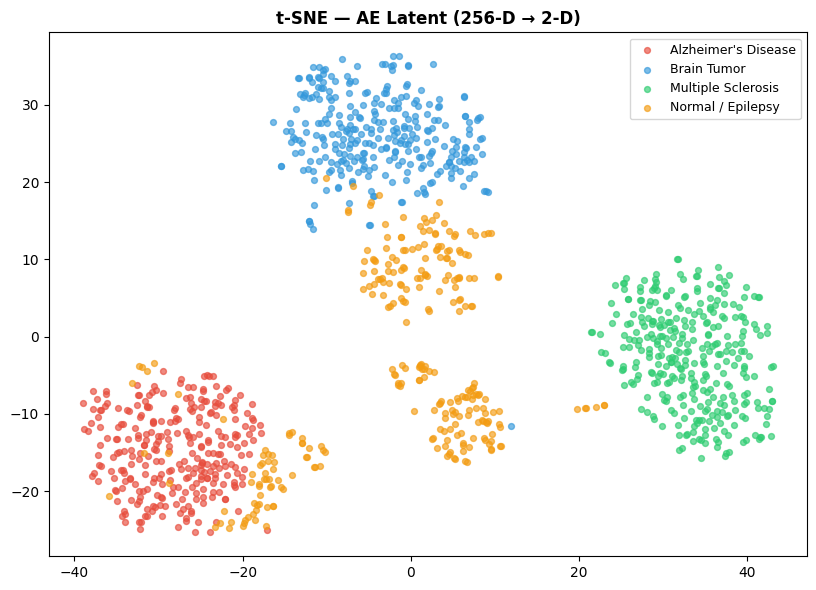

✅ t-SNE complete


In [9]:
N_TSNE  = min(1200, len(X_train_ae))
idx_tsne = np.random.choice(len(X_train_ae), N_TSNE, replace=False)
print(f'⏳ t-SNE on {N_TSNE} samples from AE latent space...')

tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,
            random_state=SEED, init='pca', learning_rate='auto')
X_2d = tsne.fit_transform(X_train_ae[idx_tsne])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_tsne = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for ax, (X_src, title) in zip(axes, [(X_2d, 'AE Latent (256-D → 2-D)'),
                                      (X_2d, 'AE Latent (256-D → 2-D)')]):
    for cls_id, cname in enumerate(CLASS_NAMES):
        mask = y_train[idx_tsne] == cls_id
        ax.scatter(X_src[mask, 0], X_src[mask, 1],
                   c=colors_tsne[cls_id], label=cname, alpha=0.65, s=18)
    ax.set_title(f't-SNE — {title}', fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    break

axes[1].set_visible(False)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/tsne_plot.png', dpi=150)
plt.show()
print('✅ t-SNE complete')

### 5D — Choose Representation

In [10]:
if USE_AE:
    X_train_reduced = X_train_ae
    X_test_reduced  = X_test_ae
    REPR_NAME = f'Autoencoder ({AE_LATENT_DIM}-D)'
else:
    X_train_reduced = X_train_pca
    X_test_reduced  = X_test_pca
    REPR_NAME = f'PCA ({N_PCA}-D)'

print(f'✅ Using : {REPR_NAME}')
print(f'   X_train_reduced: {X_train_reduced.shape}')
print(f'   X_test_reduced : {X_test_reduced.shape}')

✅ Using : Autoencoder (256-D)
   X_train_reduced: (3040, 256)
   X_test_reduced : (640, 256)


---
## ⚖️ STEP 6 — SMOTETomek Oversampling

📊 Class distribution BEFORE SMOTE:
   Class 0 (Alzheimer's Disease): 720
   Class 1 (Brain Tumor): 776
   Class 2 (Multiple Sclerosis): 796
   Class 3 (Normal / Epilepsy): 748

⏳ Applying SMOTETomek...

📊 Class distribution AFTER SMOTETomek:
   Class 0 (Alzheimer's Disease): 794
   Class 1 (Brain Tumor): 795
   Class 2 (Multiple Sclerosis): 796
   Class 3 (Normal / Epilepsy): 793

✅ 3040 → 3178 training samples


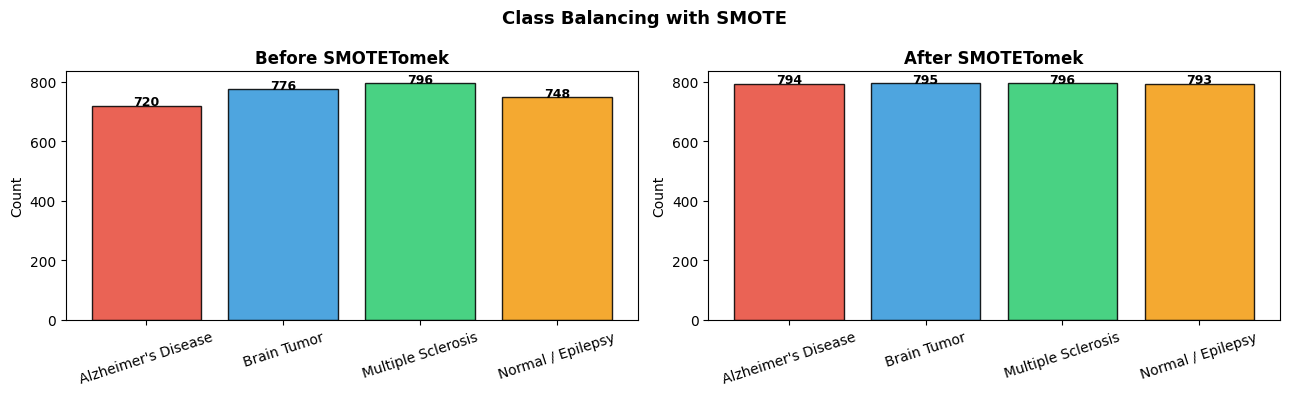

In [11]:
print('📊 Class distribution BEFORE SMOTE:')
for cls_id, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f'   Class {cls_id} ({CLASS_NAMES[cls_id]}): {cnt}')

if SMOTE_STRATEGY == 'SMOTETomek':
    resampler = SMOTETomek(smote=SMOTE(k_neighbors=5, random_state=SEED),
                           random_state=SEED)
elif SMOTE_STRATEGY == 'SMOTE':
    resampler = SMOTE(k_neighbors=5, random_state=SEED)
else:
    from imblearn.over_sampling import BorderlineSMOTE
    resampler = BorderlineSMOTE(random_state=SEED)

print(f'\n⏳ Applying {SMOTE_STRATEGY}...')
X_train_sm, y_train_sm = resampler.fit_resample(X_train_reduced, y_train)

print(f'\n📊 Class distribution AFTER {SMOTE_STRATEGY}:')
for cls_id, cnt in zip(*np.unique(y_train_sm, return_counts=True)):
    print(f'   Class {cls_id} ({CLASS_NAMES[cls_id]}): {cnt}')
print(f'\n✅ {len(y_train)} → {len(y_train_sm)} training samples')

# ── Before / After bar chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (y_d, title) in zip(axes,
    [(y_train, 'Before SMOTETomek'), (y_train_sm, f'After {SMOTE_STRATEGY}')]):
    cnts = [np.sum(y_d == i) for i in range(NUM_CLASSES)]
    bars = ax.bar(CLASS_NAMES, cnts, color=colors_cls, edgecolor='black', alpha=0.87)
    ax.set_title(title, fontweight='bold'); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=18)
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(cnt), ha='center', fontsize=9, fontweight='bold')
plt.suptitle('Class Balancing with SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/smote_distribution.png', dpi=150)
plt.show()

---
## 🤖 STEP 7 — Meta-Classifier Training
### 7A — Shared Scaler for Classifiers

In [12]:
clf_scaler = StandardScaler()
X_tr = clf_scaler.fit_transform(X_train_sm)
X_te = clf_scaler.transform(X_test_reduced)
print(f'✅ Classifier scaler fit  |  X_tr: {X_tr.shape}  |  X_te: {X_te.shape}')

# Tracker
results = {}

def evaluate_clf(name, clf, X_tr_, X_te_, y_tr_, y_te_, verbose=True):
    t0 = time.time()
    clf.fit(X_tr_, y_tr_)
    preds  = clf.predict(X_te_)
    probas = clf.predict_proba(X_te_) if hasattr(clf, 'predict_proba') else None
    acc    = accuracy_score(y_te_, preds)
    f1     = f1_score(y_te_, preds, average='weighted')
    auc_sc = roc_auc_score(y_te_, probas, multi_class='ovr',
                           average='weighted') if probas is not None else None
    elapsed = time.time() - t0
    results[name] = {'clf': clf, 'preds': preds, 'probas': probas,
                     'acc': acc, 'f1': f1, 'auc': auc_sc, 'time': elapsed}
    if verbose:
        auc_str = f'{auc_sc:.4f}' if auc_sc else 'N/A'
        print(f'  [{name:35s}]  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_str}  ({elapsed:.1f}s)')
    return clf

✅ Classifier scaler fit  |  X_tr: (3178, 256)  |  X_te: (640, 256)


### 7B — ANN (Multi-Layer Perceptron)

In [13]:
ann = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128, 64),
    activation='relu', solver='adam',
    batch_size=256, max_iter=300,
    learning_rate='adaptive',
    learning_rate_init=1e-3,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=15,
    random_state=SEED
)
print('🏋️ Training ANN...')
evaluate_clf('ANN (MLP 512-256-128-64)', ann, X_tr, X_te, y_train_sm, y_test)

🏋️ Training ANN...
  [ANN (MLP 512-256-128-64)           ]  Acc=0.9734  F1=0.9733  AUC=0.9966  (2.9s)


MLPClassifier(batch_size=256, early_stopping=True,
              hidden_layer_sizes=(512, 256, 128, 64), learning_rate='adaptive',
              max_iter=300, n_iter_no_change=15, random_state=42)

### 7C — SVM (RBF Kernel)

In [14]:
svm = SVC(
    kernel='rbf', C=10.0, gamma='scale',
    probability=True, class_weight='balanced',
    random_state=SEED, cache_size=2000
)
print('🏋️ Training SVM...')
evaluate_clf('SVM (RBF, C=10, balanced)', svm, X_tr, X_te, y_train_sm, y_test)

🏋️ Training SVM...
  [SVM (RBF, C=10, balanced)          ]  Acc=0.9734  F1=0.9734  AUC=0.9961  (2.3s)


SVC(C=10.0, cache_size=2000, class_weight='balanced', probability=True,
    random_state=42)

### 7D — XGBoost with Optuna Hyperparameter Tuning

In [15]:
# ── Optuna objective ──────────────────────────────────────────────────────────
def xgb_objective(trial):
    params = {
        'n_estimators':       trial.suggest_int('n_estimators', 200, 600),
        'max_depth':          trial.suggest_int('max_depth', 4, 8),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':          trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight':   trial.suggest_int('min_child_weight', 1, 10),
        'gamma':              trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha':          trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda':         trial.suggest_float('reg_lambda', 0.5, 2.0),
        'use_label_encoder':  False,
        'eval_metric':        'mlogloss',
        'tree_method':        'hist',
        'device':             'cuda' if DEVICE == 'cuda' else 'cpu',
        'random_state':       SEED,
    }
    clf = xgb.XGBClassifier(**params)
    # 3-fold CV on a subset for speed
    cv_acc = cross_val_score(clf, X_tr[:2000], y_train_sm[:2000],
                             cv=3, scoring='accuracy', n_jobs=-1).mean()
    return cv_acc

print(f'⏳ Optuna tuning XGBoost ({N_OPTUNA_TRIALS} trials)...')
study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(xgb_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

best_params = study.best_params
best_params.update({'use_label_encoder': False, 'eval_metric': 'mlogloss',
                    'tree_method': 'hist',
                    'device': 'cuda' if DEVICE == 'cuda' else 'cpu',
                    'random_state': SEED})
print(f'\n✅ Best CV acc: {study.best_value:.4f}')
print(f'   Best params: {best_params}')

xgb_clf = xgb.XGBClassifier(**best_params)
print('\n🏋️ Training XGBoost with best params...')
evaluate_clf('XGBoost (Optuna tuned)', xgb_clf, X_tr, X_te, y_train_sm, y_test)

⏳ Optuna tuning XGBoost (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


✅ Best CV acc: 0.9800
   Best params: {'n_estimators': 305, 'max_depth': 6, 'learning_rate': 0.12769841247931393, 'subsample': 0.6330008075550968, 'colsample_bytree': 0.7782907234138147, 'min_child_weight': 9, 'gamma': 0.38397369296832834, 'reg_alpha': 0.3940228829710361, 'reg_lambda': 1.4553525654709252, 'use_label_encoder': False, 'eval_metric': 'mlogloss', 'tree_method': 'hist', 'device': 'cuda', 'random_state': 42}

🏋️ Training XGBoost with best params...
  [XGBoost (Optuna tuned)             ]  Acc=0.9688  F1=0.9686  AUC=0.9963  (1.6s)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7782907234138147, device='cuda',
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=0.38397369296832834, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.12769841247931393,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=9, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=305, n_jobs=None,
              num_parallel_tree=None, ...)

### 7E — Random Forest

In [16]:
rf = RandomForestClassifier(
    n_estimators=400, max_depth=None,
    min_samples_leaf=2, max_features='sqrt',
    class_weight='balanced', n_jobs=-1,
    random_state=SEED
)
print('🏋️ Training Random Forest...')
evaluate_clf('Random Forest (400 trees)', rf, X_tr, X_te, y_train_sm, y_test)

🏋️ Training Random Forest...
  [Random Forest (400 trees)          ]  Acc=0.9641  F1=0.9639  AUC=0.9960  (17.3s)


RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=400, n_jobs=-1, random_state=42)

### 7F — Stacking Meta-Learner (Highest Accuracy)

In [17]:
# Stacking: base estimators pass probas to a Logistic Regression meta-learner
# This typically gives the best accuracy of all approaches
print('🏋️ Training Stacking Ensemble (this takes a few minutes)...')

base_estimators = [
    ('xgb', xgb.XGBClassifier(**{**best_params, 'n_estimators': 300})),
    ('rf',  RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                   class_weight='balanced', random_state=SEED)),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale',
                probability=True, random_state=SEED)),
]

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=500, C=1.0,
                                       random_state=SEED, n_jobs=-1),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)
evaluate_clf('Stacking (XGB+RF+SVM → LR)', stacking_clf,
             X_tr, X_te, y_train_sm, y_test)
print('✅ All classifiers trained!')

🏋️ Training Stacking Ensemble (this takes a few minutes)...
  [Stacking (XGB+RF+SVM → LR)         ]  Acc=0.9734  F1=0.9733  AUC=0.9971  (58.4s)
✅ All classifiers trained!


---
## 🏆 STEP 8 — Adaptive Weighted Soft-Voting Ensemble

In [18]:
# ── Use all classifiers with probas ───────────────────────────────────────────
clf_names_ordered = [
    'ANN (MLP 512-256-128-64)',
    'SVM (RBF, C=10, balanced)',
    'XGBoost (Optuna tuned)',
    'Random Forest (400 trees)',
    'Stacking (XGB+RF+SVM → LR)'
]

# ── Adaptive weights: softmax over accuracy^2 (sharpen the best) ──────────────
clf_accs = np.array([results[n]['acc'] for n in clf_names_ordered])
exp_acc  = np.exp(clf_accs ** 2 * 10)
weights  = exp_acc / exp_acc.sum()

print('🏆 Adaptive ensemble weights:')
for n, w, a in zip(clf_names_ordered, weights, clf_accs):
    bar = '█' * int(w * 40)
    print(f'   {n:38s}: w={w:.4f} acc={a:.4f}  {bar}')

# ── Weighted soft voting ───────────────────────────────────────────────────────
all_probas_stack = np.array([results[n]['probas'] for n in clf_names_ordered])
ensemble_proba   = np.einsum('k,knc->nc', weights, all_probas_stack)
ensemble_preds   = np.argmax(ensemble_proba, axis=1)

ens_acc = accuracy_score(y_test, ensemble_preds)
ens_f1  = f1_score(y_test, ensemble_preds, average='weighted')
ens_auc = roc_auc_score(y_test, ensemble_proba,
                        multi_class='ovr', average='weighted')
results['Adaptive Ensemble'] = {
    'preds': ensemble_preds, 'probas': ensemble_proba,
    'acc': ens_acc, 'f1': ens_f1, 'auc': ens_auc, 'time': 0
}

print(f'\n🎯 ADAPTIVE ENSEMBLE  |  Acc={ens_acc:.4f}  F1={ens_f1:.4f}  AUC={ens_auc:.4f}')

🏆 Adaptive ensemble weights:
   ANN (MLP 512-256-128-64)              : w=0.2107 acc=0.9734  ████████
   SVM (RBF, C=10, balanced)             : w=0.2107 acc=0.9734  ████████
   XGBoost (Optuna tuned)                : w=0.1923 acc=0.9688  ███████
   Random Forest (400 trees)             : w=0.1757 acc=0.9641  ███████
   Stacking (XGB+RF+SVM → LR)            : w=0.2107 acc=0.9734  ████████

🎯 ADAPTIVE ENSEMBLE  |  Acc=0.9719  F1=0.9718  AUC=0.9968


---
## 📐 STEP 9 — Probability Calibration

In [19]:
print('⏳ Calibrating XGBoost probabilities...')
cal_xgb = CalibratedClassifierCV(xgb_clf, method='isotonic', cv='prefit')
cal_xgb.fit(X_tr, y_train_sm)
cal_proba = cal_xgb.predict_proba(X_te)
cal_preds = np.argmax(cal_proba, axis=1)
cal_acc   = accuracy_score(y_test, cal_preds)
cal_auc   = roc_auc_score(y_test, cal_proba, multi_class='ovr', average='weighted')
print(f'✅ Calibrated XGBoost  |  Acc={cal_acc:.4f}  AUC={cal_auc:.4f}')

results['Calibrated XGBoost'] = {
    'preds': cal_preds, 'probas': cal_proba,
    'acc': cal_acc, 'f1': f1_score(y_test, cal_preds, average='weighted'),
    'auc': cal_auc, 'time': 0
}

⏳ Calibrating XGBoost probabilities...
✅ Calibrated XGBoost  |  Acc=0.9672  AUC=0.9810


---
## 📊 STEP 10 — Results Visualization

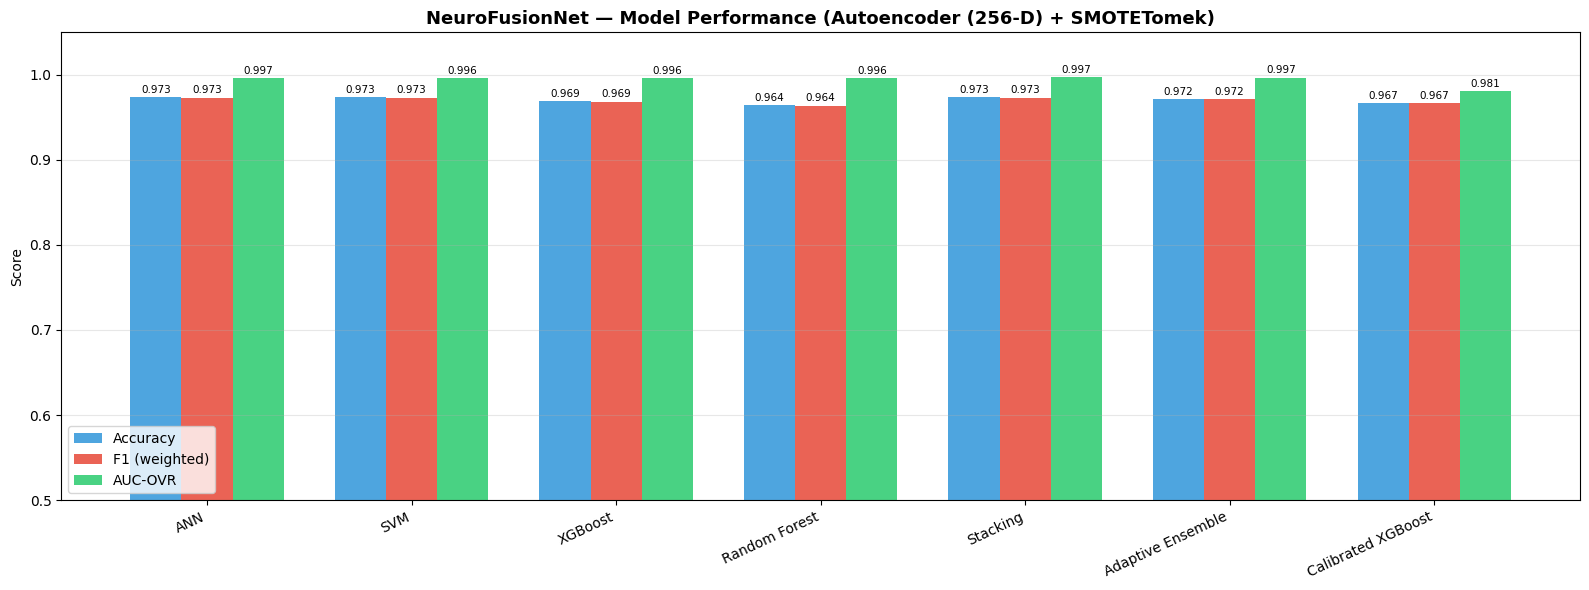

In [20]:
# ── Performance comparison bar chart ─────────────────────────────────────────
all_model_names = clf_names_ordered + ['Adaptive Ensemble', 'Calibrated XGBoost']
accs_all  = [results[n]['acc'] for n in all_model_names]
f1s_all   = [results[n]['f1']  for n in all_model_names]
aucs_all  = [results[n]['auc'] for n in all_model_names]

x = np.arange(len(all_model_names))
w = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
b1 = ax.bar(x - w,  accs_all, w, label='Accuracy',      color='#3498db', alpha=0.87)
b2 = ax.bar(x,      f1s_all,  w, label='F1 (weighted)', color='#e74c3c', alpha=0.87)
b3 = ax.bar(x + w,  aucs_all, w, label='AUC-OVR',       color='#2ecc71', alpha=0.87)

ax.set_ylabel('Score'); ax.set_ylim(0.5, 1.05)
ax.set_title(f'NeuroFusionNet — Model Performance ({REPR_NAME} + {SMOTE_STRATEGY})',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([n.split('(')[0].strip() for n in all_model_names],
                   rotation=25, ha='right')
ax.legend(); ax.grid(axis='y', alpha=0.3)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=7.5)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/model_comparison.png', dpi=150)
plt.show()

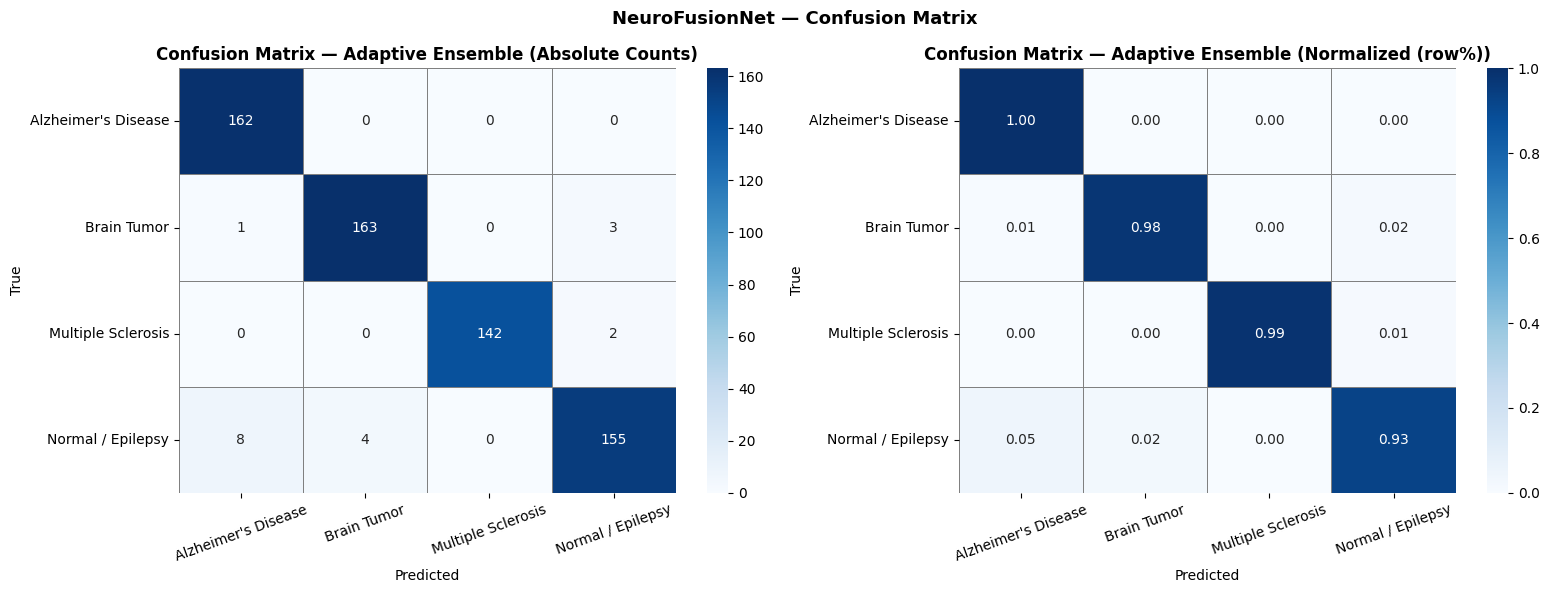


📋 Detailed Classification Report (Adaptive Ensemble):
                     precision    recall  f1-score   support

Alzheimer's Disease     0.9474    1.0000    0.9730       162
        Brain Tumor     0.9760    0.9760    0.9760       167
 Multiple Sclerosis     1.0000    0.9861    0.9930       144
  Normal / Epilepsy     0.9688    0.9281    0.9480       167

           accuracy                         0.9719       640
          macro avg     0.9730    0.9726    0.9725       640
       weighted avg     0.9723    0.9719    0.9718       640



In [21]:
# ── Confusion matrices (best model = Adaptive Ensemble) ───────────────────────
cm      = confusion_matrix(y_test, ensemble_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (data, fmt, title) in zip(axes, [
    (cm,      'd',   'Absolute Counts'),
    (cm_norm, '.2f', 'Normalized (row%)'),
]):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='grey')
    ax.set_title(f'Confusion Matrix — Adaptive Ensemble ({title})',
                 fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('NeuroFusionNet — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150)
plt.show()

print('\n📋 Detailed Classification Report (Adaptive Ensemble):')
print(classification_report(y_test, ensemble_preds, target_names=CLASS_NAMES, digits=4))

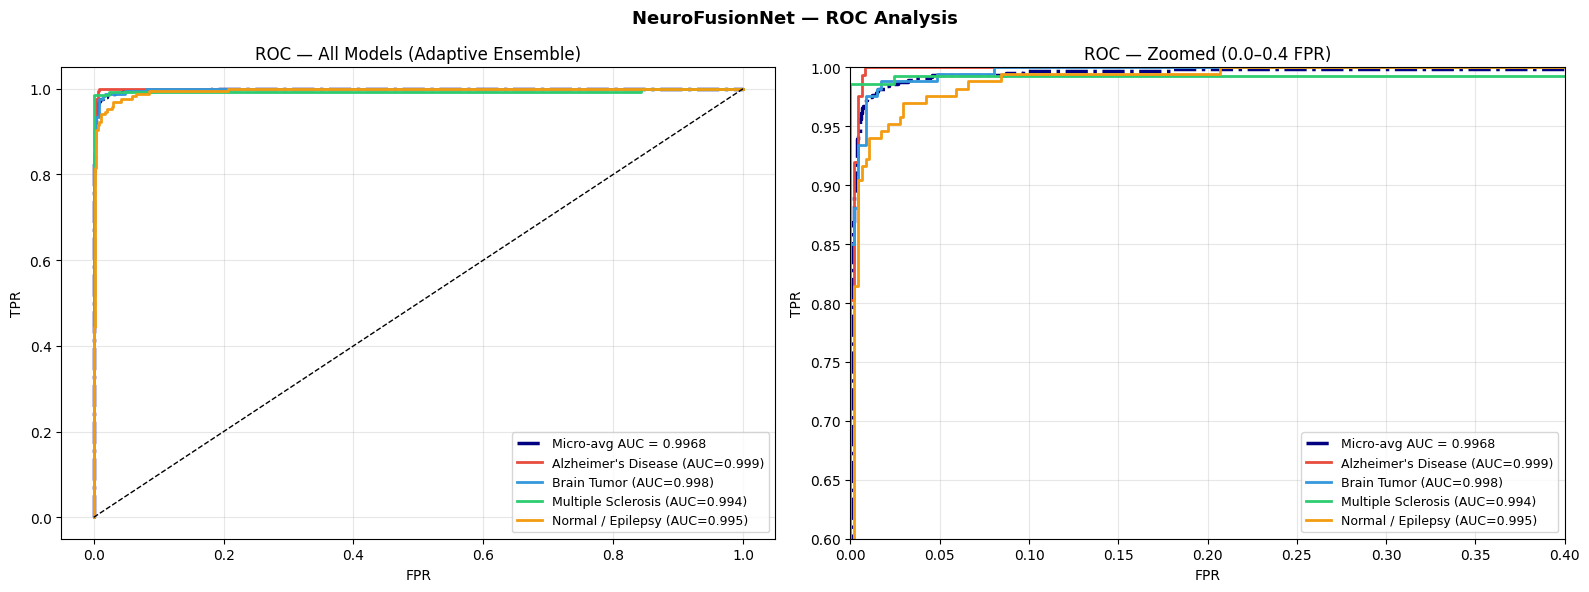

In [22]:
# ── ROC Curves ────────────────────────────────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=list(range(NUM_CLASSES)))
colors_roc = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), ensemble_proba.ravel())
auc_micro = auc(fpr_micro, tpr_micro)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax in axes:
    ax.plot(fpr_micro, tpr_micro, color='navy', lw=2.5,
            label=f'Micro-avg AUC = {auc_micro:.4f}', linestyle='-.')
    for i, (cname, c) in enumerate(zip(CLASS_NAMES, colors_roc)):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], ensemble_proba[:, i])
        ax.plot(fpr_i, tpr_i, lw=2, color=c,
                label=f'{cname} (AUC={auc(fpr_i, tpr_i):.3f})')
    ax.plot([0,1],[0,1],'k--',lw=1); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)

axes[0].set_title('ROC — All Models (Adaptive Ensemble)')
axes[1].set_title('ROC — Zoomed (0.0–0.4 FPR)')
axes[1].set_xlim(0, 0.4); axes[1].set_ylim(0.6, 1.0)

plt.suptitle('NeuroFusionNet — ROC Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/roc_curves.png', dpi=150)
plt.show()

---
## 🔍 STEP 11 — SHAP Explainability

⏳ Computing SHAP values (TreeExplainer on XGBoost)...


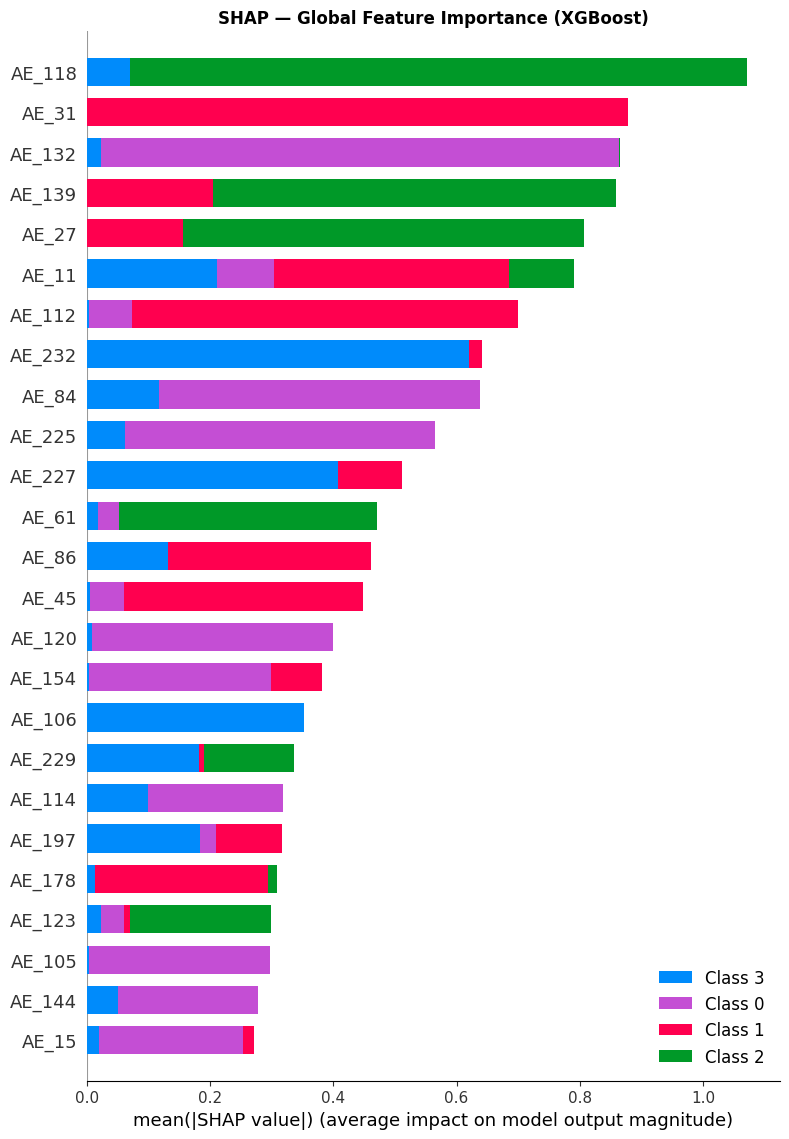

✅ SHAP analysis complete


In [23]:
print('⏳ Computing SHAP values (TreeExplainer on XGBoost)...')
explainer   = shap.TreeExplainer(xgb_clf)
N_SHAP      = min(300, len(X_te))
shap_values = explainer.shap_values(X_te[:N_SHAP])

feat_labels = [f'{"AE" if USE_AE else "PC"}_{i+1}'
               for i in range(X_tr.shape[1])]

# ── Global summary (bar) ──────────────────────────────────────────────────────
plt.figure(figsize=(11, 6))
if isinstance(shap_values, list):
    # Multi-class: plot mean absolute SHAP across all classes
    mean_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    shap.summary_plot(mean_shap, X_te[:N_SHAP],
                      feature_names=feat_labels, plot_type='bar',
                      max_display=25, show=False)
else:
    shap.summary_plot(shap_values, X_te[:N_SHAP],
                      feature_names=feat_labels, plot_type='bar',
                      max_display=25, show=False)
plt.title('SHAP — Global Feature Importance (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class beeswarm (class 1 = Brain Tumor example) ────────────────────────
if isinstance(shap_values, list) and len(shap_values) > 1:
    plt.figure(figsize=(11, 6))
    shap.summary_plot(shap_values[1], X_te[:N_SHAP],
                      feature_names=feat_labels, max_display=20, show=False)
    plt.title(f'SHAP Beeswarm — Class 1: {CLASS_NAMES[1]}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/shap_beeswarm_class1.png', dpi=150, bbox_inches='tight')
    plt.show()

print('✅ SHAP analysis complete')

---
## 🖥️ STEP 12 — Final Dashboard & Summary Report

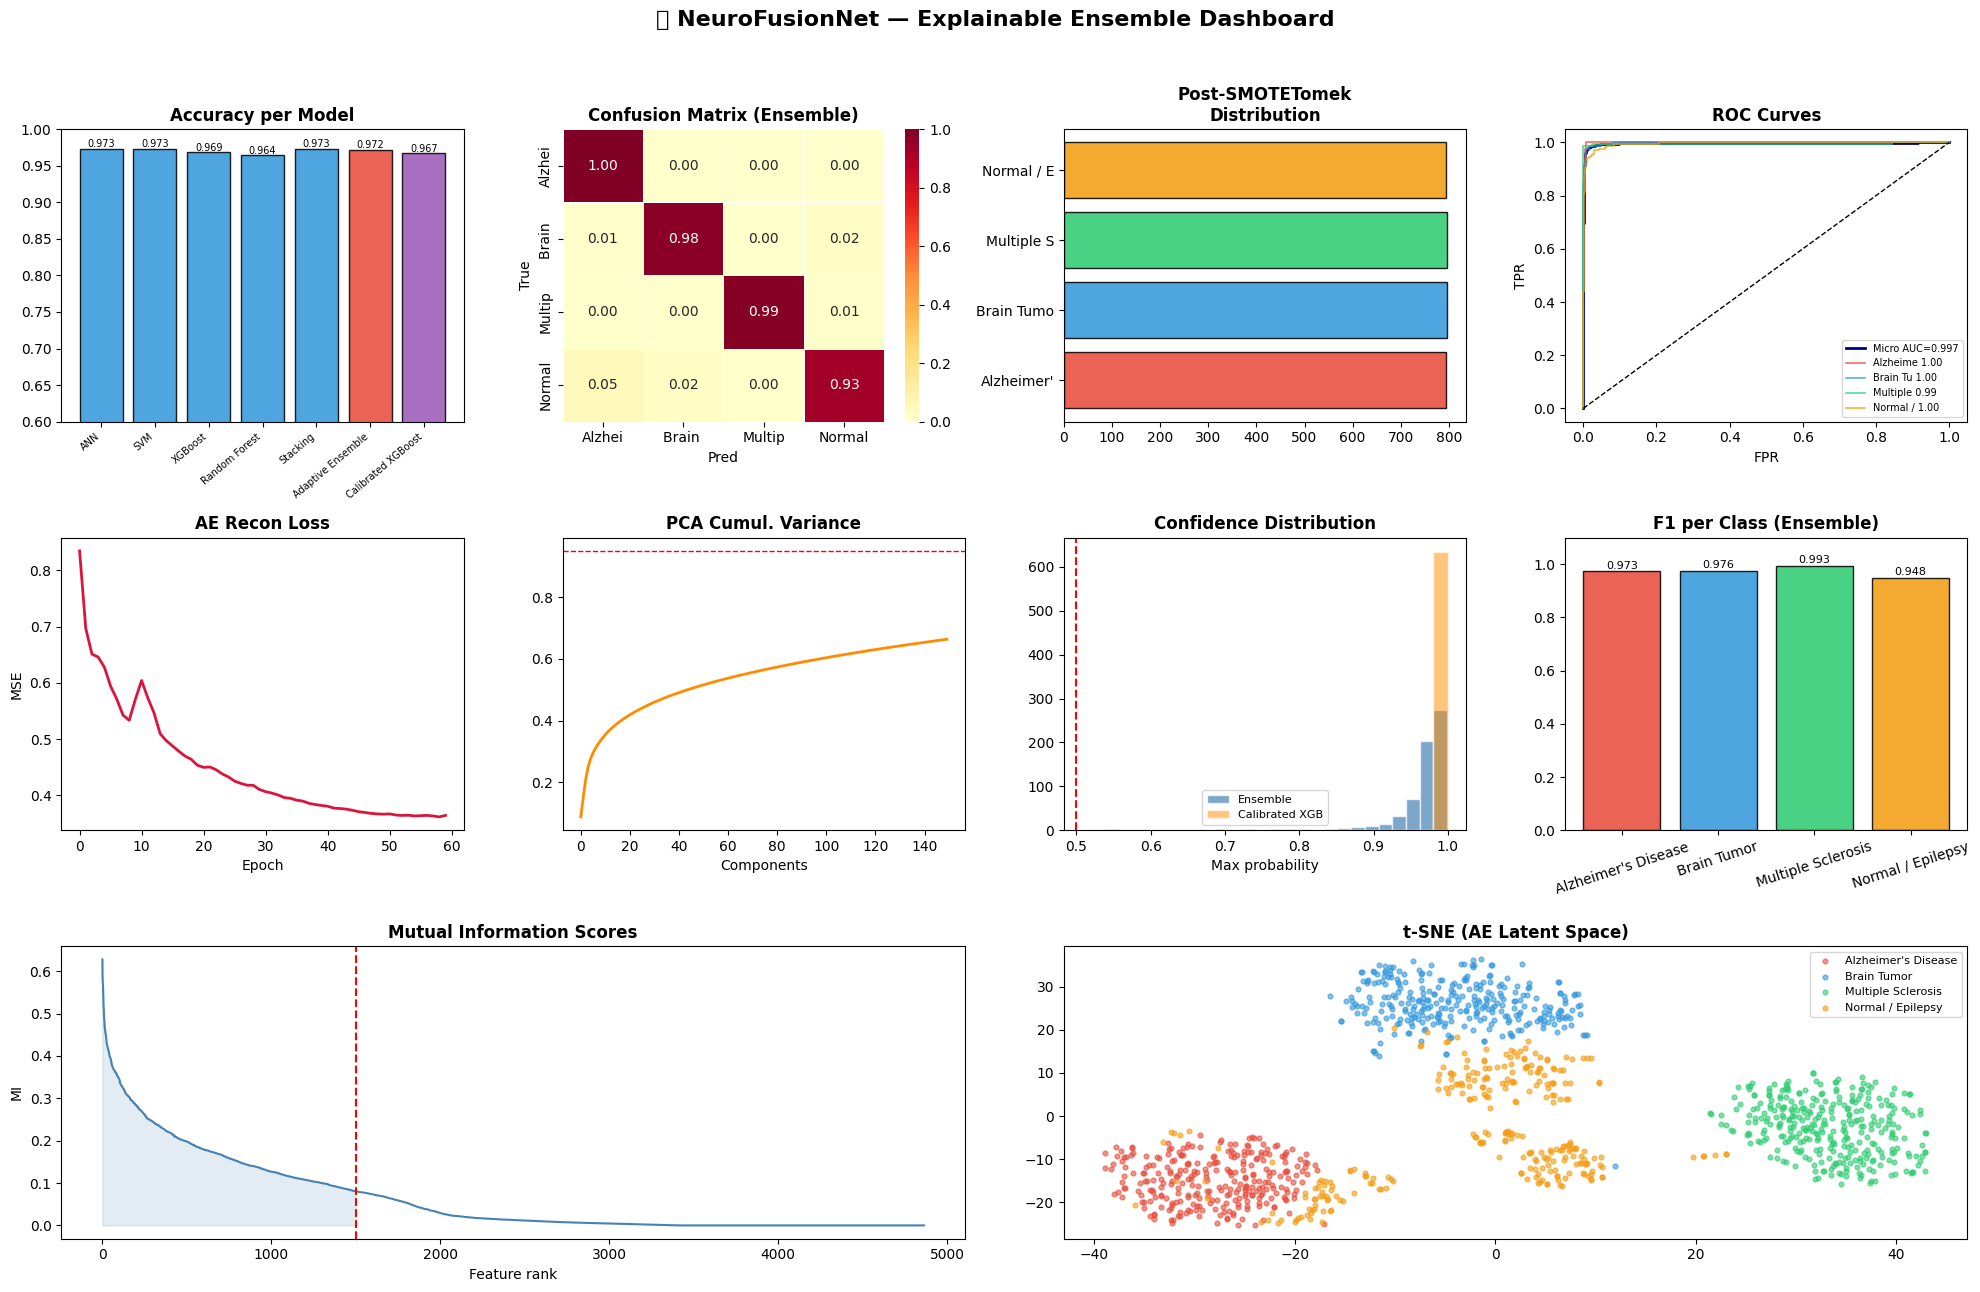

✅ Dashboard saved


In [24]:
# ── Confidence distribution ───────────────────────────────────────────────────
max_conf_ens = ensemble_proba.max(axis=1)
max_conf_cal = cal_proba.max(axis=1)

# ── Build dashboard figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 13))
fig.suptitle('🧠 NeuroFusionNet — Explainable Ensemble Dashboard',
             fontsize=16, fontweight='bold', y=0.99)

# (1) Accuracy comparison
ax1 = fig.add_subplot(3, 4, 1)
short_names = [n.split('(')[0].strip() for n in all_model_names]
bar_c = ['#3498db'] * (len(all_model_names) - 2) + ['#e74c3c', '#9b59b6']
ax1.bar(range(len(accs_all)), accs_all, color=bar_c, edgecolor='black', alpha=0.87)
ax1.set_xticks(range(len(accs_all)))
ax1.set_xticklabels(short_names, rotation=40, ha='right', fontsize=7)
ax1.set_title('Accuracy per Model', fontweight='bold'); ax1.set_ylim(0.6, 1.0)
for i, v in enumerate(accs_all):
    ax1.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=7)

# (2) Confusion matrix (normalized)
ax2 = fig.add_subplot(3, 4, 2)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax2,
            xticklabels=[c[:6] for c in CLASS_NAMES],
            yticklabels=[c[:6] for c in CLASS_NAMES], linewidths=0.4)
ax2.set_title('Confusion Matrix (Ensemble)', fontweight='bold')
ax2.set_xlabel('Pred'); ax2.set_ylabel('True')

# (3) Class distribution post-SMOTE
ax3 = fig.add_subplot(3, 4, 3)
cnts_sm = [np.sum(y_train_sm == i) for i in range(NUM_CLASSES)]
ax3.barh([c[:10] for c in CLASS_NAMES], cnts_sm,
         color=colors_cls, edgecolor='black', alpha=0.87)
ax3.set_title(f'Post-{SMOTE_STRATEGY}\nDistribution', fontweight='bold')

# (4) ROC micro-avg
ax4 = fig.add_subplot(3, 4, 4)
ax4.plot(fpr_micro, tpr_micro, 'navy', lw=2,
         label=f'Micro AUC={auc_micro:.3f}')
for i, (c, col) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fi, ti, _ = roc_curve(y_test_bin[:, i], ensemble_proba[:, i])
    ax4.plot(fi, ti, lw=1.2, color=col, alpha=0.8,
             label=f'{c[:8]} {auc(fi,ti):.2f}')
ax4.plot([0,1],[0,1],'k--',lw=1); ax4.legend(fontsize=7)
ax4.set_title('ROC Curves', fontweight='bold')
ax4.set_xlabel('FPR'); ax4.set_ylabel('TPR')

# (5) AE reconstruction loss
ax5 = fig.add_subplot(3, 4, 5)
ax5.plot(ae_losses, color='crimson', lw=2)
ax5.set_title('AE Recon Loss', fontweight='bold')
ax5.set_xlabel('Epoch'); ax5.set_ylabel('MSE')

# (6) PCA cumvar
ax6 = fig.add_subplot(3, 4, 6)
ax6.plot(cumvar[:150], color='darkorange', lw=2)
ax6.axhline(0.95, color='red', linestyle='--', lw=1)
ax6.set_title('PCA Cumul. Variance', fontweight='bold')
ax6.set_xlabel('Components')

# (7) Confidence histogram
ax7 = fig.add_subplot(3, 4, 7)
ax7.hist(max_conf_ens, bins=25, color='steelblue', alpha=0.7,
         label='Ensemble', edgecolor='white')
ax7.hist(max_conf_cal, bins=25, color='darkorange', alpha=0.5,
         label='Calibrated XGB', edgecolor='white')
ax7.axvline(0.5, color='red', linestyle='--')
ax7.set_title('Confidence Distribution', fontweight='bold')
ax7.legend(fontsize=8); ax7.set_xlabel('Max probability')

# (8) F1 per class (Ensemble)
ax8 = fig.add_subplot(3, 4, 8)
from sklearn.metrics import f1_score as f1_per
f1_per_class = f1_score(y_test, ensemble_preds, average=None)
ax8.bar(CLASS_NAMES, f1_per_class, color=colors_cls, edgecolor='black', alpha=0.87)
ax8.set_ylim(0, 1.1); ax8.set_title('F1 per Class (Ensemble)', fontweight='bold')
ax8.tick_params(axis='x', rotation=18)
for i, v in enumerate(f1_per_class):
    ax8.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

# (9-12) MI score plot + t-SNE summary
ax9 = fig.add_subplot(3, 4, (9, 10))
ax9.plot(np.sort(mi_scores)[::-1], color='steelblue', lw=1.5)
ax9.axvline(N_MI_FEATURES, color='red', linestyle='--')
ax9.fill_between(range(N_MI_FEATURES),
                 np.sort(mi_scores)[::-1][:N_MI_FEATURES], alpha=0.15, color='steelblue')
ax9.set_title('Mutual Information Scores', fontweight='bold')
ax9.set_xlabel('Feature rank'); ax9.set_ylabel('MI')

ax10 = fig.add_subplot(3, 4, (11, 12))
for cls_id, cname in enumerate(CLASS_NAMES):
    mask = y_train[idx_tsne] == cls_id
    ax10.scatter(X_2d[mask, 0], X_2d[mask, 1],
                 c=colors_tsne[cls_id], label=cname, alpha=0.6, s=12)
ax10.set_title('t-SNE (AE Latent Space)', fontweight='bold')
ax10.legend(fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(f'{SAVE_DIR}/dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved')

In [25]:
# ── Print final summary table ─────────────────────────────────────────────────
print('\n' + '='*75)
print('       🧠 NeuroFusionNet — FINAL PERFORMANCE SUMMARY')
print('='*75)
print(f'  Representation  : {REPR_NAME}')
print(f'  Oversampling    : {SMOTE_STRATEGY}')
print(f'  Train samples   : {len(y_train)} → {len(y_train_sm)} (after SMOTE)')
print(f'  Test samples    : {len(y_test)}')
print('='*75)
print(f'  {"Model":<42} {"Accuracy":>8}  {"F1-W":>7}  {"AUC":>7}')
print('-'*75)
for n in all_model_names:
    r   = results[n]
    auc_str = f'{r["auc"]:.4f}' if r['auc'] else '   N/A'
    marker = ' ◄ BEST' if r['acc'] == max(accs_all) else ''
    print(f'  {n:<42} {r["acc"]:>8.4f}  {r["f1"]:>7.4f}  {auc_str:>7}{marker}')
print('='*75)


       🧠 NeuroFusionNet — FINAL PERFORMANCE SUMMARY
  Representation  : Autoencoder (256-D)
  Oversampling    : SMOTETomek
  Train samples   : 3040 → 3178 (after SMOTE)
  Test samples    : 640
  Model                                      Accuracy     F1-W      AUC
---------------------------------------------------------------------------
  ANN (MLP 512-256-128-64)                     0.9734   0.9733   0.9966 ◄ BEST
  SVM (RBF, C=10, balanced)                    0.9734   0.9734   0.9961 ◄ BEST
  XGBoost (Optuna tuned)                       0.9688   0.9686   0.9963
  Random Forest (400 trees)                    0.9641   0.9639   0.9960
  Stacking (XGB+RF+SVM → LR)                   0.9734   0.9733   0.9971 ◄ BEST
  Adaptive Ensemble                            0.9719   0.9718   0.9968
  Calibrated XGBoost                           0.9672   0.9671   0.9810


---
## 💾 STEP 13 — Save All Models & Artifacts

In [26]:
# ── Save sklearn / numpy objects ──────────────────────────────────────────────
save_objects = {
    'input_scaler':   input_scaler,
    'clf_scaler':     clf_scaler,
    'pca':            pca,
    'mi_top_idx':     mi_top_idx,
    'corr_keep_mask': keep_mask,
    'ann':            ann,
    'svm':            svm,
    'xgboost':        xgb_clf,
    'rf':             rf,
    'stacking':       stacking_clf,
    'calibrated_xgb': cal_xgb,
    'ensemble_weights': weights,
    'best_xgb_params':  best_params,
}

for name, obj in save_objects.items():
    path = f'{SAVE_DIR}/{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'  💾 {path}')

# ── Save summary JSON ─────────────────────────────────────────────────────────
summary = {
    'representation':        REPR_NAME,
    'smote_strategy':        SMOTE_STRATEGY,
    'n_features_raw':        int(X_train_raw.shape[1]),
    'n_features_after_mi':   int(X_train_mi.shape[1]),
    'n_features_after_corr': int(X_train_fs.shape[1]),
    'n_features_reduced':    int(X_train_reduced.shape[1]),
    'train_samples_before':  int(len(y_train)),
    'train_samples_after':   int(len(y_train_sm)),
    'test_samples':          int(len(y_test)),
    'class_names':           CLASS_NAMES,
    'best_xgb_params':       {k: (float(v) if isinstance(v, (np.floating,)) else
                                  int(v) if isinstance(v, (np.integer,)) else v)
                              for k, v in best_params.items()},
    'results': {
        n: {'accuracy':     float(results[n]['acc']),
            'f1_weighted':  float(results[n]['f1']),
            'auc_ovr':      float(results[n]['auc']) if results[n]['auc'] else None}
        for n in all_model_names
    }
}
with open(f'{SAVE_DIR}/summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f'\n✅ All artifacts saved to: {SAVE_DIR}')

  💾 /content/neurofusionnet_outputs/input_scaler.pkl
  💾 /content/neurofusionnet_outputs/clf_scaler.pkl
  💾 /content/neurofusionnet_outputs/pca.pkl
  💾 /content/neurofusionnet_outputs/mi_top_idx.pkl
  💾 /content/neurofusionnet_outputs/corr_keep_mask.pkl
  💾 /content/neurofusionnet_outputs/ann.pkl
  💾 /content/neurofusionnet_outputs/svm.pkl
  💾 /content/neurofusionnet_outputs/xgboost.pkl
  💾 /content/neurofusionnet_outputs/rf.pkl
  💾 /content/neurofusionnet_outputs/stacking.pkl
  💾 /content/neurofusionnet_outputs/calibrated_xgb.pkl
  💾 /content/neurofusionnet_outputs/ensemble_weights.pkl
  💾 /content/neurofusionnet_outputs/best_xgb_params.pkl

✅ All artifacts saved to: /content/neurofusionnet_outputs


---
## 📤 STEP 14 — Download Outputs

In [27]:
import shutil
from google.colab import files

zip_path = '/content/NeuroFusionNet_outputs.zip'
shutil.make_archive('/content/NeuroFusionNet_outputs', 'zip', SAVE_DIR)
print(f'📦 Archive created: {zip_path}')
files.download(zip_path)
print('✅ Download triggered')

📦 Archive created: /content/NeuroFusionNet_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download triggered


---
## 🔮 STEP 15 — Single-Sample Inference

In [28]:
def predict_fused_vector(raw_vector: np.ndarray, verbose=True) -> dict:
    """
    Full pipeline inference on a single 4864-D fused feature vector.
    Returns dict: predicted_class, label, confidence, all_probabilities
    """
    v = raw_vector.reshape(1, -1).astype(np.float32)

    # 1. Clean + scale
    v = input_scaler.transform(clean_features(v))

    # 2. MI selection
    v = v[:, mi_top_idx]

    # 3. Correlation filter
    v = v[:, keep_mask]

    # 4. Dimensionality reduction
    if USE_AE:
        ae.eval()
        with torch.no_grad():
            v = ae.encode(torch.FloatTensor(v).to(DEVICE)).cpu().numpy()
    else:
        v = pca.transform(v)

    # 5. Classifier scaler
    v = clf_scaler.transform(v)

    # 6. Adaptive ensemble
    proba_list = np.array([results[n]['clf'].predict_proba(v)
                           for n in clf_names_ordered])
    ens_p = np.einsum('k,knc->nc', weights, proba_list)[0]
    pred  = int(np.argmax(ens_p))

    result = {
        'predicted_class': pred,
        'predicted_label': CLASS_NAMES[pred],
        'confidence':      float(ens_p[pred]),
        'all_probabilities': {CLASS_NAMES[i]: float(ens_p[i])
                              for i in range(NUM_CLASSES)}
    }

    if verbose:
        print(f'  Predicted : {result["predicted_label"]}')
        print(f'  Confidence: {result["confidence"]*100:.1f}%')
        for cls, prob in result['all_probabilities'].items():
            bar = '█' * int(prob * 35)
            print(f'  {cls:28s}: {prob:.3f}  {bar}')
    return result


# ── Demo on 3 random test samples ────────────────────────────────────────────
for _ in range(3):
    idx_demo = np.random.randint(0, len(X_test_raw))
    true_lbl = CLASS_NAMES[y_test[idx_demo]]
    print(f'\n{'─'*55}')
    print(f'  Sample #{idx_demo}  |  True: {true_lbl}')
    predict_fused_vector(X_test_raw[idx_demo])


───────────────────────────────────────────────────────
  Sample #323  |  True: Brain Tumor
  Predicted : Brain Tumor
  Confidence: 92.2%
  Alzheimer's Disease         : 0.004  
  Brain Tumor                 : 0.922  ████████████████████████████████
  Multiple Sclerosis          : 0.006  
  Normal / Epilepsy           : 0.068  ██

───────────────────────────────────────────────────────
  Sample #34  |  True: Brain Tumor
  Predicted : Brain Tumor
  Confidence: 98.8%
  Alzheimer's Disease         : 0.001  
  Brain Tumor                 : 0.988  ██████████████████████████████████
  Multiple Sclerosis          : 0.003  
  Normal / Epilepsy           : 0.008  

───────────────────────────────────────────────────────
  Sample #481  |  True: Alzheimer's Disease
  Predicted : Alzheimer's Disease
  Confidence: 99.3%
  Alzheimer's Disease         : 0.993  ██████████████████████████████████
  Brain Tumor                 : 0.002  
  Multiple Sclerosis          : 0.001  
  Normal / Epilepsy       